# Crypto perpetuals: 150 candidate models from two validation years

[`06_linear`](06_linear.ipynb) worked through what a penalty does to a feature set that is one
economic quantity - the premium of the perpetual over spot - measured many ways. The L1 path
reduced to a single column and the ranking stopped moving. Gradient boosting meets the same
feature set with a different constraint: a tree does not weight columns, it splits on them, and
on a block of near-duplicates it can split on one measurement of the premium after another. That
is a way to describe the training window in great detail without adding any information.

Three dials control how far it goes, and this notebook varies all three:

- **Capacity**, set by `num_leaves`: how many regions one tree may carve the feature space into.
- **The loss function**, which decides what "got wrong" means. Squared error weights an
  observation by the square of its error; absolute error and Huber do not. Eight-hour crypto
  returns are heavy-tailed enough for that to be a real choice rather than a formality.
- **When to stop**, set by the number of trees. A boosted model has a meaningful state at every
  iteration, so this notebook scores each configuration at ten points along its own training run.

**The arithmetic of that is the reason to read this notebook carefully.** Fifteen declared
configurations at ten checkpoints is 150 candidate models, and this case study has the shortest
usable history of the nine: `05_evaluation` set two walk-forward folds from the liquid funding
data that exists, so every one of those 150 numbers is measured on two validation years of a
market whose structure changed over them. The more candidates a search has, the better its best
member looks for reasons that have nothing to do with the data - and here the candidate count is
large while the evidence each candidate is judged on is small.

**Learning objectives.** By the end of this notebook you will be able to:

- Read a declared gradient boosting grid and say what each configuration varies.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and say
  whether an apparent peak is a turning point or the highest of ten noisy readings.
- Say why the choice of loss function is a statement about the label's tails, and relate that to
  what a rank-based metric rewards.
- Judge a result by the number of candidates behind it and the amount of validation data under
  it, rather than by its rank in a table.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to, and Section 6.8 the multiple-testing problem this grid creates.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) fitted the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`13_backtest`](13_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared crypto perpetuals gradient boosting population on the walk-forward folds."""

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABEL = "fwd_ret_8h"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""

In [3]:
study = open_study(
    "crypto_perps_funding", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which label, and which models

The label is the same one the linear notebook used: `fwd_ret_8h`, the return over the eight
hours after the decision timestamp. Keeping it fixed is what makes the two populations
comparable - the families differ, the target does not.

In [4]:
declared_labels(study, "gbm")

('fwd_dir_8h', 'fwd_dir_8h_3c', 'fwd_ret_24h', 'fwd_ret_8h')

The menu at `config/training/{label}.yaml` lists 15 named configurations under `gbm:`, and each
resolves to a preset in `case_studies/config/lgb/`. The grid is a product of two axes:

- **Five capacity profiles.** `default` uses the library's own leaf count; the rest fix it at 7,
  15, 31 and 63. Leaf count is the direct control on how finely one tree may partition the
  feature space. On a feature set this redundant the dial does something particular: with many
  near-copies of the premium available, a deeper tree can keep splitting on one measurement of
  it after another and describe the training window in fine detail without adding information.
- **Three objectives.** `mse` minimizes squared error, `mae` absolute error, and `huber` behaves
  like squared error for small residuals and like absolute error beyond a threshold derived from
  each fold's own label spread.

Every configuration runs the same number of boosting iterations with the same learning rate, so
the grid isolates capacity and loss rather than confounding them with training length.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=[LABEL],
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_ret_8h""","""default_mse""","""""","""objective=regression, seed=42"""
"""gbm""","""fwd_ret_8h""","""default_mae""","""""","""objective=regression_l1, seed=…"
"""gbm""","""fwd_ret_8h""","""default_huber""","""""","""objective=huber, seed=42"""
"""gbm""","""fwd_ret_8h""","""leaves_7_mse""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_8h""","""leaves_7_mae""","""""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_8h""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_8h""","""leaves_31_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_8h""","""leaves_63_mse""","""""","""bagging_fraction=0.8, bagging_…"


## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those: it is a fraction of the training labels' standard deviation,
so it is a different number on every fold and is resolved from that fold's own data.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** A row that
  differs is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [6]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,"datetime[μs, UTC]","datetime[μs, UTC]"
"""default_huber""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""default_mae""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""default_mse""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""leaves_15_huber""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""leaves_15_mae""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
…,…,…,…,…,…,…,…
"""leaves_63_mae""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""leaves_63_mse""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""leaves_7_huber""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Preparation happens once per fold and is shared by every configuration, because slicing the
window and cleaning the rows depends on the data and not on the model. The run walks folds on
the outside and configurations on the inside for the same reason: one prepared fold is held at a
time rather than the whole set.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [7]:
# `POPULATION_NAME` is derived here rather than in the parameters cell above, because a
# parameterized run replaces `LABEL` in a cell inserted *after* that one: a name built up
# there would carry the default label into every other label's run.
population_name = POPULATION_NAME or f"crypto_perps_funding-gbm-{LABEL}-validation-v1"
execution, population = run_model_population(study, resolved, population_name=population_name)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

      fold 0: training n_train=31,402 n_val=18,542 trees=500 num_leaves=? obj=regression


      fold 0: done in 0s


      fold 1: training n_train=23,681 n_val=16,738 trees=500 num_leaves=? obj=regression


      fold 1: done in 0s


      fold 0: training n_train=31,402 n_val=18,542 trees=500 num_leaves=? obj=regression_l1


...

      fold 0: training n_train=31,402 n_val=18,542 trees=500 num_leaves=63 obj=huber


      fold 0: done in 1s


      fold 1: training n_train=23,681 n_val=16,738 trees=500 num_leaves=63 obj=huber


      fold 1: done in 1s


15 configurations fitted
population crypto_perps_funding-gbm-fwd_ret_8h-validation-v1: 150 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("crypto_perps_funding", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_8h"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration and checkpoint. `ic_mean` is the **information coefficient**: on each
validation timestamp, rank the contracts by the model's prediction, rank them by the return they
went on to earn, correlate the two rankings, and average that correlation over the validation
period.

`auc_mean_daily` reads the same predictions the way a classifier is read. At each validation
timestamp, take every pair of one contract that went up and one that went down, and count the
fraction of those pairs the model ranked in the right order; average that over the validation
period, with one half being what a coin achieves. It is computed within each timestamp and then
averaged, the same shape as `ic_mean`, which is what makes the two answer the same question.

`auc_n_days` is smaller than `ic_n_days`, and the gap is structural rather than a data problem.
A pair needs one contract that went up and one that went down, so a timestamp on which the whole
cross-section moved together defines no AUC, while a rank correlation is still defined there.
It costs 540 of 2,189 timestamps here. `full_coverage` refers to `ic_n_days` only.

The two together answer a question neither answers alone. This model is fitted to the size of
the next return; a model fitted to `fwd_dir_8h`, the direction cut from that same return at that
same horizon, is fitted only to its sign. `LABEL` is a parameter of this notebook, so the same
code run against that label produces the classifier and the registry holds both. Which
formulation suits the data is not settled by argument, because a squared-error fit spends its
capacity on the largest returns and crypto funding returns have a heavy tail. Carrying both
readings on every model lets the comparison be made directly.

The table is sorted by IC, and the top of it is the trap this notebook exists to describe. The
leading row is the maximum of 150 numbers. Reading it as the result of one experiment would
attribute to the model whatever the stopping point contributed, and the section below measures
how large that contribution is before anything is concluded from the ranking.

In [8]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "auc_mean_daily",
    "auc_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("ic_mean", descending=True)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

full_days = int(catalog.get_column("ic_n_days").max())
catalog = catalog.with_columns(full_coverage=pl.col("ic_n_days") == full_days)

print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each")
catalog.select(
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "auc_mean_daily",
    "auc_n_days",
    "full_coverage",
).head(15)

150 candidate models: 15 configurations
at 10 checkpoints each


config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,auc_mean_daily,auc_n_days,full_coverage
str,i64,f64,f64,f64,f64,f64,bool
"""leaves_15_huber""",150,0.032149,0.011436,2189.0,0.507803,1649.0,true
"""leaves_15_huber""",100,0.031311,0.015016,2189.0,0.508409,1649.0,true
"""leaves_31_huber""",100,0.031125,0.011361,2189.0,0.508642,1649.0,true
"""leaves_31_huber""",150,0.029978,0.00933,2189.0,0.509711,1649.0,true
"""leaves_63_huber""",100,0.029935,0.005414,2189.0,0.507966,1649.0,true
…,…,…,…,…,…,…,…
"""leaves_15_huber""",400,0.028976,0.009043,2189.0,0.509881,1649.0,true
"""leaves_63_mae""",150,0.02897,0.00064,2189.0,0.514266,1649.0,true
"""leaves_63_huber""",150,0.02863,0.004539,2189.0,0.507237,1649.0,true


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

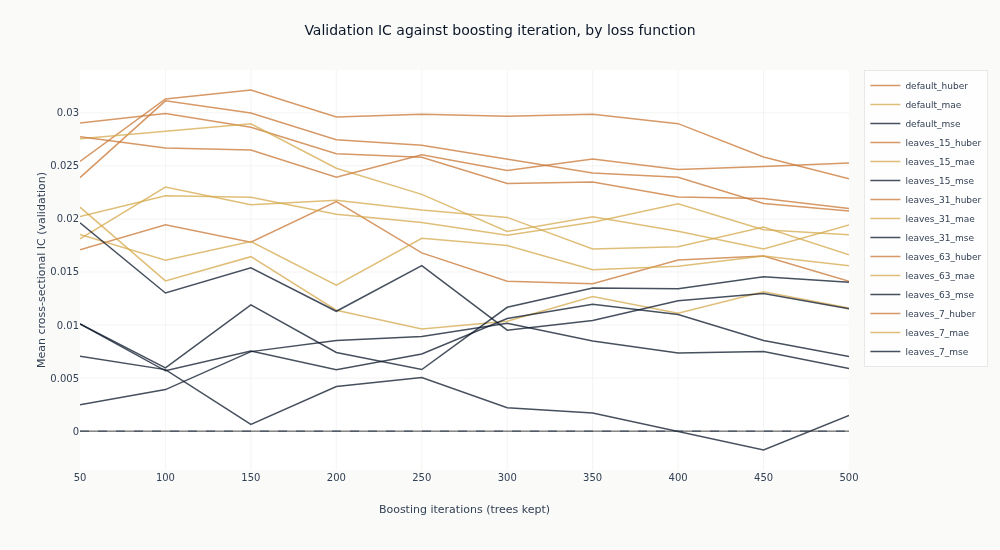

In [9]:
curves = catalog.filter("full_coverage").sort("config_name", "checkpoint_value")
objectives = {"mse": COLORS["blue"], "mae": COLORS["amber"], "huber": COLORS["copper"]}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name."""
    return next((key for key in objectives if name.endswith(key)), "mse")


fig_curves = go.Figure()
for config_name in curves.get_column("config_name").unique(maintain_order=True):
    series = curves.filter(pl.col("config_name") == config_name)
    fig_curves.add_trace(
        go.Scatter(
            x=series.get_column("checkpoint_value").to_list(),
            y=series.get_column("ic_mean").to_list(),
            mode="lines",
            name=config_name,
            line=dict(color=objectives[objective_of(config_name)], width=1.5),
            opacity=0.75,
        )
    )
fig_curves.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by loss function",
    height=550,
    width=1000,
    margin=dict(t=70),
    legend=dict(font=dict(size=9)),
)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)")
fig_curves.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_curves,
    "Line chart of mean validation information coefficient against boosting iteration, one line "
    "per configuration, coloured by loss function: blue for squared error, amber for absolute "
    "error, copper for Huber. A dashed line marks zero. Almost every line stays above zero across "
    "the whole range, with one squared-error line dipping just below it at the later "
    "checkpoints. The copper Huber lines sit at the top of the band and the blue squared-error "
    "lines at the bottom, separated from the first checkpoints onwards, and most lines reach "
    "their highest point early and drift sideways or down after it.",
)

### Whether the loss function is what separates them

The curves are coloured by objective because that is the axis with a mechanism behind it. If
heavy tails are steering the squared-error fits, the three colours should separate, and they
should separate more as trees are added, since each additional tree is fitted to the residuals
the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact.

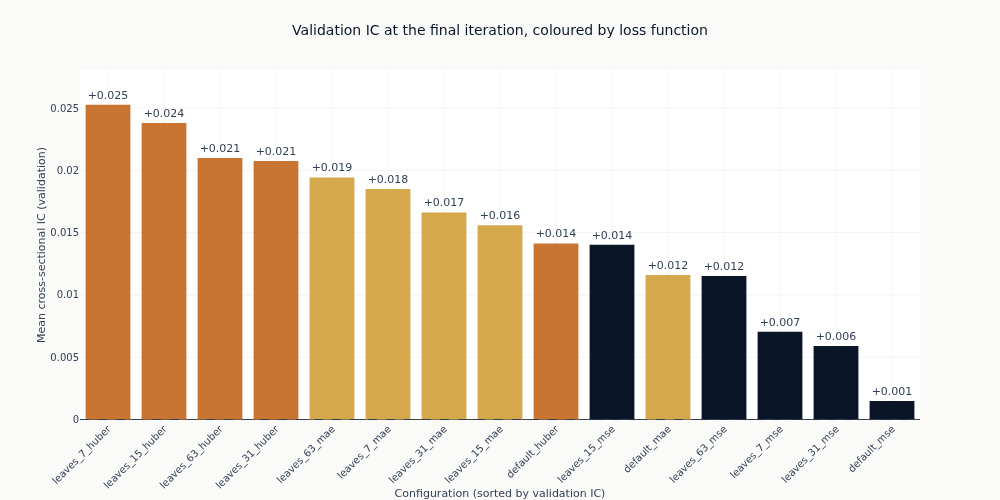

In [10]:
final_iteration = int(catalog.get_column("checkpoint_value").max())
final = (
    catalog.filter(pl.col("checkpoint_value") == final_iteration)
    .filter("full_coverage")
    .with_columns(objective=pl.col("config_name").map_elements(objective_of, return_dtype=pl.Utf8))
    .sort("ic_mean", descending=True)
)

fig_obj = go.Figure(
    go.Bar(
        x=final.get_column("config_name").to_list(),
        y=final.get_column("ic_mean").to_list(),
        marker_color=[objectives[value] for value in final.get_column("objective")],
        text=[f"{value:+.3f}" for value in final.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_obj.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_obj.update_layout(
    title="Validation IC at the final iteration, coloured by loss function",
    height=500,
    width=1000,
    showlegend=False,
    margin=dict(t=70),
)
fig_obj.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_obj.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_obj,
    "Bar chart of mean validation information coefficient for every full-coverage configuration "
    "at its final boosting iteration, sorted descending and coloured by loss function, against a "
    "dashed zero line. Every bar is above the line. The colours group rather than interleave: "
    "copper Huber bars occupy the left of the ranking, amber absolute-error bars the middle, and "
    "blue squared-error bars the right, so the loss function orders the configurations more than "
    "the leaf count does.",
)

### How much the checkpoint moves a configuration

One number per configuration: the range its IC covers across its own ten checkpoints. This is
the quantity that decides whether choosing a stopping point is a decision worth making carefully
or one being made by noise. A configuration whose IC varies more across its own training run
than the configurations vary among themselves is one where the checkpoint, not the model, is
doing the ranking.

In [11]:
spread = (
    curves.group_by("config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort("checkpoint_range", descending=True)
)
across_configs = float(final.get_column("ic_mean").max() - final.get_column("ic_mean").min())
print(f"IC range across configurations at the final iteration: {across_configs:.4f}")
print(
    f"median IC range within one configuration: {spread.get_column('checkpoint_range').median():.4f}"
)
spread

IC range across configurations at the final iteration: 0.0238
median IC range within one configuration: 0.0084


config_name,ic_min,ic_max,ic_final,checkpoint_range
str,f64,f64,f64,f64
"""leaves_63_mae""",0.017166,0.02897,0.019426,0.011804
"""default_mae""",0.009617,0.021106,0.011605,0.011489
"""leaves_31_huber""",0.020749,0.031125,0.020749,0.010376
"""leaves_63_mse""",0.009515,0.01964,0.011524,0.010125
"""leaves_63_huber""",0.020991,0.029935,0.020991,0.008944
…,…,…,…,…
"""leaves_31_mae""",0.01662,0.023002,0.01662,0.006382
"""leaves_7_mse""",0.005685,0.01195,0.007037,0.006266
"""leaves_15_mae""",0.013746,0.018531,0.015589,0.004785


## 5. What to notice

**The loss function is the axis that matters here, and it separates almost cleanly.** Ordered by
median information coefficient at the final iteration, Huber leads, absolute error follows, and
squared error trails - and unlike a grid where the objectives interleave, here the Huber
configurations as a group sit above the squared-error ones as a group. The mechanism is the
label. Eight-hour perpetual returns are heavy-tailed, squared error weights an observation by
the square of its error, so the largest moves dominate what each successive tree is fitted to.
The information coefficient is a rank correlation and cares about order rather than magnitude,
so accuracy on the extremes buys nothing it measures. **An objective is a claim about which
errors matter, and squared error makes a claim this metric does not reward.**

**Nine of the fifteen configurations reach their highest IC in the first fifth of training.**
The grid runs 500 iterations; most configurations do their useful learning well before that and
then drift. On a feature set that is one quantity measured many ways, that is what one would
expect - there is not much independent structure to find, and the trees that follow are splitting
on near-copies of columns already used. The practical reading is that the iteration count in
these presets is generous for this data, and that a shorter schedule would lose little.

**The checkpoint still moves the answer, by about a third of what the model choice does.** Across
the fifteen configurations at fixed training length the IC spans a wider range than a single
configuration spans across its own ten checkpoints. So the stopping point is a smaller dial than
the model here than it was for a longer-history case study - but it is not negligible, and the
leading row of the table is the maximum of 150 numbers either way. The fixed-iteration chart is
the comparison that does not require choosing anything after the fact.

**Two folds is the number to hold on to.** Every statement above rests on two validation years of
a market that changed structurally over them, and the search that produced it had 150 members.
That combination - many candidates, little data - is the one where a best member looks convincing
for reasons unrelated to the data. Nothing here is a small effect measured precisely; it is a
moderate effect measured on a short sample, and the honest summary is the direction rather than
the magnitude. [`12_model_analysis`](12_model_analysis.ipynb) is where the search is accounted
for across families.

**Gradient boosting finds more than the penalty grid did.** The linear notebook's grid sat close
to zero and its L1 path reduced to a single volatility column. Every configuration here is
positive at the end of training and the weakest of them is above what the linear family reached.
A tree can condition one feature on another, and on this feature set that appears to be worth
something a weighted sum of the same columns is not.

**None of this selects anything.** IC measures whether predictions rank contracts correctly, not
whether a strategy trading them makes money after costs and funding - and those are unusually far
apart here, because funding is a cash flow the holder receives or pays regardless of what the
price does, so a position can pay while its price prediction is wrong. Selection is on validation
backtest Sharpe over the population just published, in [`13_backtest`](13_backtest.ipynb), where
the checkpoint is part of what is selected.

**Known limitations.** Two folds, and a short one at that. The IC is an average of per-timestamp
rank correlations with no adjustment for the serial dependence overlapping eight-hour returns
create, so it is a diagnostic rather than a test, and it carries no interval that would say
whether these configurations differ from one another. The grid varies capacity and loss at a
fixed learning rate. And every number is measured on validation folds already read many times by
the time a case study reaches this notebook.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) asks the same question of a neural network built
for tabular data. The thing to watch is whether it prefers the same loss functions - if the tails
are what separates the objectives here, a different model class fitted with the same objectives
should separate the same way.